# 1, setup K-means class

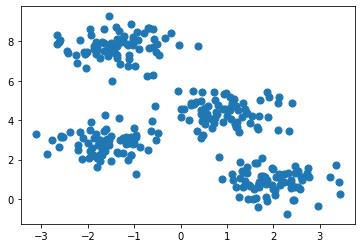

In [2]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

X, y_true = make_blobs(n_samples=300, centers=4,
                       cluster_std=0.60, random_state=0)
plt.scatter(X[:, 0], X[:, 1], s=50);

# 2, plot the data

/usr/local/lib/python3.9/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


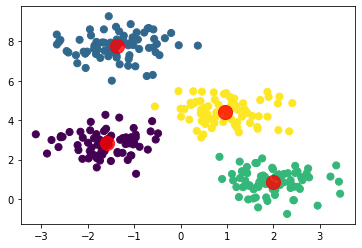

In [3]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=4)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.8);

# 3, image comression

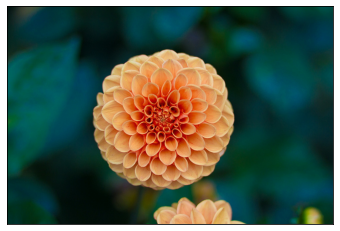

In [4]:
# Note: this requires the ``pillow`` package to be installed
from sklearn.datasets import load_sample_image
flower = load_sample_image("flower.jpg")
ax = plt.axes(xticks=[], yticks=[])
ax.imshow(flower);

In [5]:
data = flower / 255.0 # use 0...1 scale
data = data.reshape(427 * 640, 3)
data.shape

(273280, 3)

In [6]:
import warnings; warnings.simplefilter('ignore')  # Fix NumPy issues.

from sklearn.cluster import MiniBatchKMeans
kmeans = MiniBatchKMeans(16)
kmeans.fit(data)
new_colors = kmeans.cluster_centers_[kmeans.predict(data)]


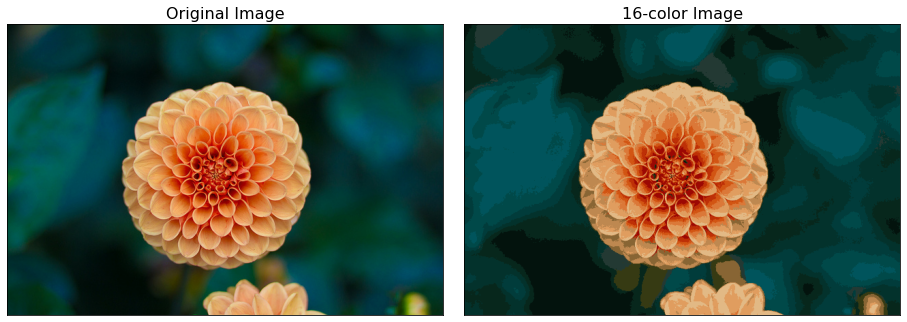

In [7]:
flower_recolored = new_colors.reshape(flower.shape)

fig, ax = plt.subplots(1, 2, figsize=(16, 6),
                       subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)

ax[0].imshow(flower)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(flower_recolored)
ax[1].set_title('16-color Image', size=16);

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

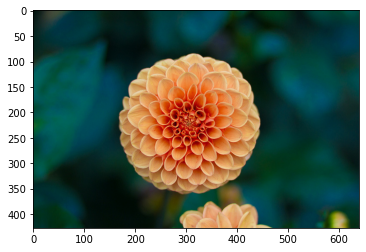

In [8]:
from google.colab import files

plt.imshow(flower)
plt.savefig("flower.png")
files.download("flower.png") 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

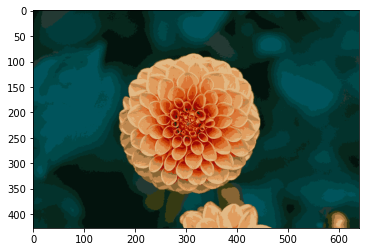

In [10]:
plt.imshow(flower_recolored)
plt.savefig("flower_recolored.png")
files.download("flower_recolored.png") 

# 4, image compression, without SKlearn

In [28]:
from skimage import io
import numpy as np
import numpy.matlib
import matplotlib.pyplot as plt
from google.colab import files
import random
from PIL import Image
import warnings; warnings.simplefilter('ignore')

K = 3
max_iters = 10

In [29]:
def init_centroids(data,K):
    c = random.sample(list(data),K)
    return c

def closest_centroids(data,c):
    K = np.size(c,0)
    idx = np.zeros((np.size(data,0),1))
    arr = np.empty((np.size(data,0),1))
    for i in range(0,K):
        y = c[i]
        temp = np.ones((np.size(data,0),1))*y
        b = np.power(np.subtract(data,temp),2)
        a = np.sum(b,axis = 1)
        a = np.asarray(a)
        a.resize((np.size(data,0),1))
        #print(np.shape(a))
        arr = np.append(arr, a, axis=1)
    arr = np.delete(arr,0,axis=1)
    idx = np.argmin(arr, axis=1)
    return idx

def compute_centroids(data,idx,K):
    n = np.size(data,1)
    centroids = np.zeros((K,n))
    for i in range(0,K):
        ci = idx==i
        ci = ci.astype(int)
        total_number = sum(ci);
        ci.resize((np.size(data,0),1))
        total_matrix = np.matlib.repmat(ci,1,n)
        ci = np.transpose(ci)
        total = np.multiply(data,total_matrix)
        centroids[i] = (1/total_number)*np.sum(total,axis=0)
    return centroids

def run_kMean(data,initial_centroids,max_iters):
    m = np.size(data,0)
    n = np.size(data,1)
    K = np.size(initial_centroids,0)
    centroids = initial_centroids
    idx = np.zeros((m,1))
    for i in range(1,max_iters):
        print('Running {}/{}'.format(i, max_iters))
        idx = closest_centroids(data,centroids)
        centroids = compute_centroids(data,idx,K)
    return centroids,idx

Saving building.png to building.png
Running 1/10
Running 2/10
Running 3/10
Running 4/10
Running 5/10
Running 6/10
Running 7/10
Running 8/10
Running 9/10


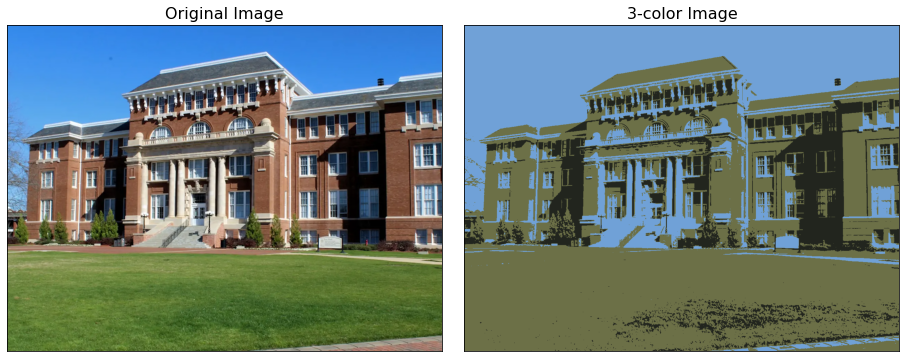

In [32]:
# Uncomment this line to upload the files if this is the first time running the code in this session.
uploaded = files.upload()
building_img = Image.open("building.png")
building = np.asarray(building_img) # building.shape is (960, 1280, 3).
building = building / 255.0 # Convert to a 0...1 scale
X = building.reshape(960 * 1280, 3) # Reshape it so it's essentially just a list of RGB values


initial_centroids = init_centroids(X,K)
centroids,idx = run_kMean(X,initial_centroids,max_iters)
idx.resize((np.size(X,0),1))
idx = closest_centroids(X,centroids)
recovered = centroids[idx]
recovered = np.reshape(recovered, (960, 1280, 3))


fig, ax = plt.subplots(1, 2, figsize=(16, 6), subplot_kw=dict(xticks=[], yticks=[]))
fig.subplots_adjust(wspace=0.05)

ax[0].imshow(building_img)
ax[0].set_title('Original Image', size=16)
ax[1].imshow(recovered)
ax[1].set_title('3-color Image', size=16);

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

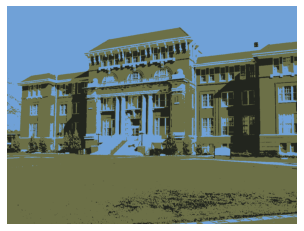

In [35]:
plt.imshow(building_img)
plt.axis('off')
plt.savefig("original.png")
files.download("original.png")

plt.imshow(recovered)
plt.savefig("recolored.png")
files.download("recolored.png") 